# Figure — R² Ablation: Sample Size

Line chart comparing R² (train & test) across eight sample-size proportions
(5 % → 100 % of training segments) for the **Generalisable** (GS config)
and **Fit-Biased** (stress-test config) models.

Data source (both curves, both configs):
- `ABBLATION_RESULTS_PAPER / Sample_Size_Uncertainty / {Generalisable,FitBiased} / Sample_Size_{p:.2f} / TrainDraws_Distribution.csv`

**Training** and **Testing** = mean ± 1 SD across the same 10 independent training draws
per level (repeat-based uncertainty band; single deterministic draw at 100%, so no band
there). Each draw yields one Train R² and one Test R², so both curves' bars come from
that same set of draws — the Test band reflects how much a model's test-set performance
varies due to which subjects/rows were drawn for training.

One figure per BP target. Set `TARGET` below to switch between SBP / DBP / MAP.

In [33]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd()))
sys.path.insert(0, str(Path("../").resolve()))

from fig_style import (
    DPI, W_FULL, W_SINGLE, ASPECT, FONT_FAMILY,
    MIN_PX_FULL, MIN_PX_SINGLE,
    apply_base_style, save_fig,
)
from local_paths import ABBLATION_RESULTS_PAPER, FIGURES_PAPER

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D

FIG_OUT = FIGURES_PAPER
FIG_OUT.mkdir(parents=True, exist_ok=True)
print(f"Output directory : {FIG_OUT.resolve()}")
print(f"Full-page  : {W_FULL:.2f} × {W_FULL*ASPECT:.2f} in  →  "
      f"{round(W_FULL*DPI)} × {round(W_FULL*ASPECT*DPI)} px @ {DPI} dpi")
print(f"Single-col : {W_SINGLE:.2f} × {W_SINGLE*ASPECT:.2f} in  →  "
      f"{round(W_SINGLE*DPI)} × {round(W_SINGLE*ASPECT*DPI)} px @ {DPI} dpi")

Output directory : C:\Users\addp972\OneDrive - City, University of London\3.PhD\9. Experiments\2.LightGBM_SHAP\Figures_SummaryTables
Full-page  : 7.48 × 4.86 in  →  3740 × 2431 px @ 500 dpi
Single-col : 3.54 × 2.30 in  →  1770 × 1150 px @ 500 dpi


## 1 · Load data

In [ ]:
# ── Change TARGET here to produce DBP or MAP figures ─────────────────────────
TARGET      = "DBP"

PROPORTIONS = [0.05, 0.10, 0.20, 0.35, 0.50, 0.65, 0.80, 1.00]
X_LABELS    = ["5%", "10%", "20%", "35%", "50%", "65%", "80%", "100%"]

UNCERTAINTY_BASE = ABBLATION_RESULTS_PAPER / "Sample_Size_Uncertainty"


def level_dir(variant: str, proportion: float) -> Path:
    return UNCERTAINTY_BASE / variant / f"Sample_Size_{proportion:.2f}"


def load_level(variant: str, proportion: float) -> pd.DataFrame:
    return pd.read_csv(level_dir(variant, proportion) / "TrainDraws_Distribution.csv")


for variant in ("Generalisable", "FitBiased"):
    missing = [p for p in PROPORTIONS if not level_dir(variant, p).exists()]
    print(f"{variant:14s}: {len(PROPORTIONS) - len(missing)}/{len(PROPORTIONS)} levels found"
          + (f"  MISSING: {missing}" if missing else ""))

Generalisable : 8/8 levels found
FitBiased     : 8/8 levels found


## 2 · Plot

Full-page  : 3740 × 2431 px
Single-col : 1770 × 1150 px


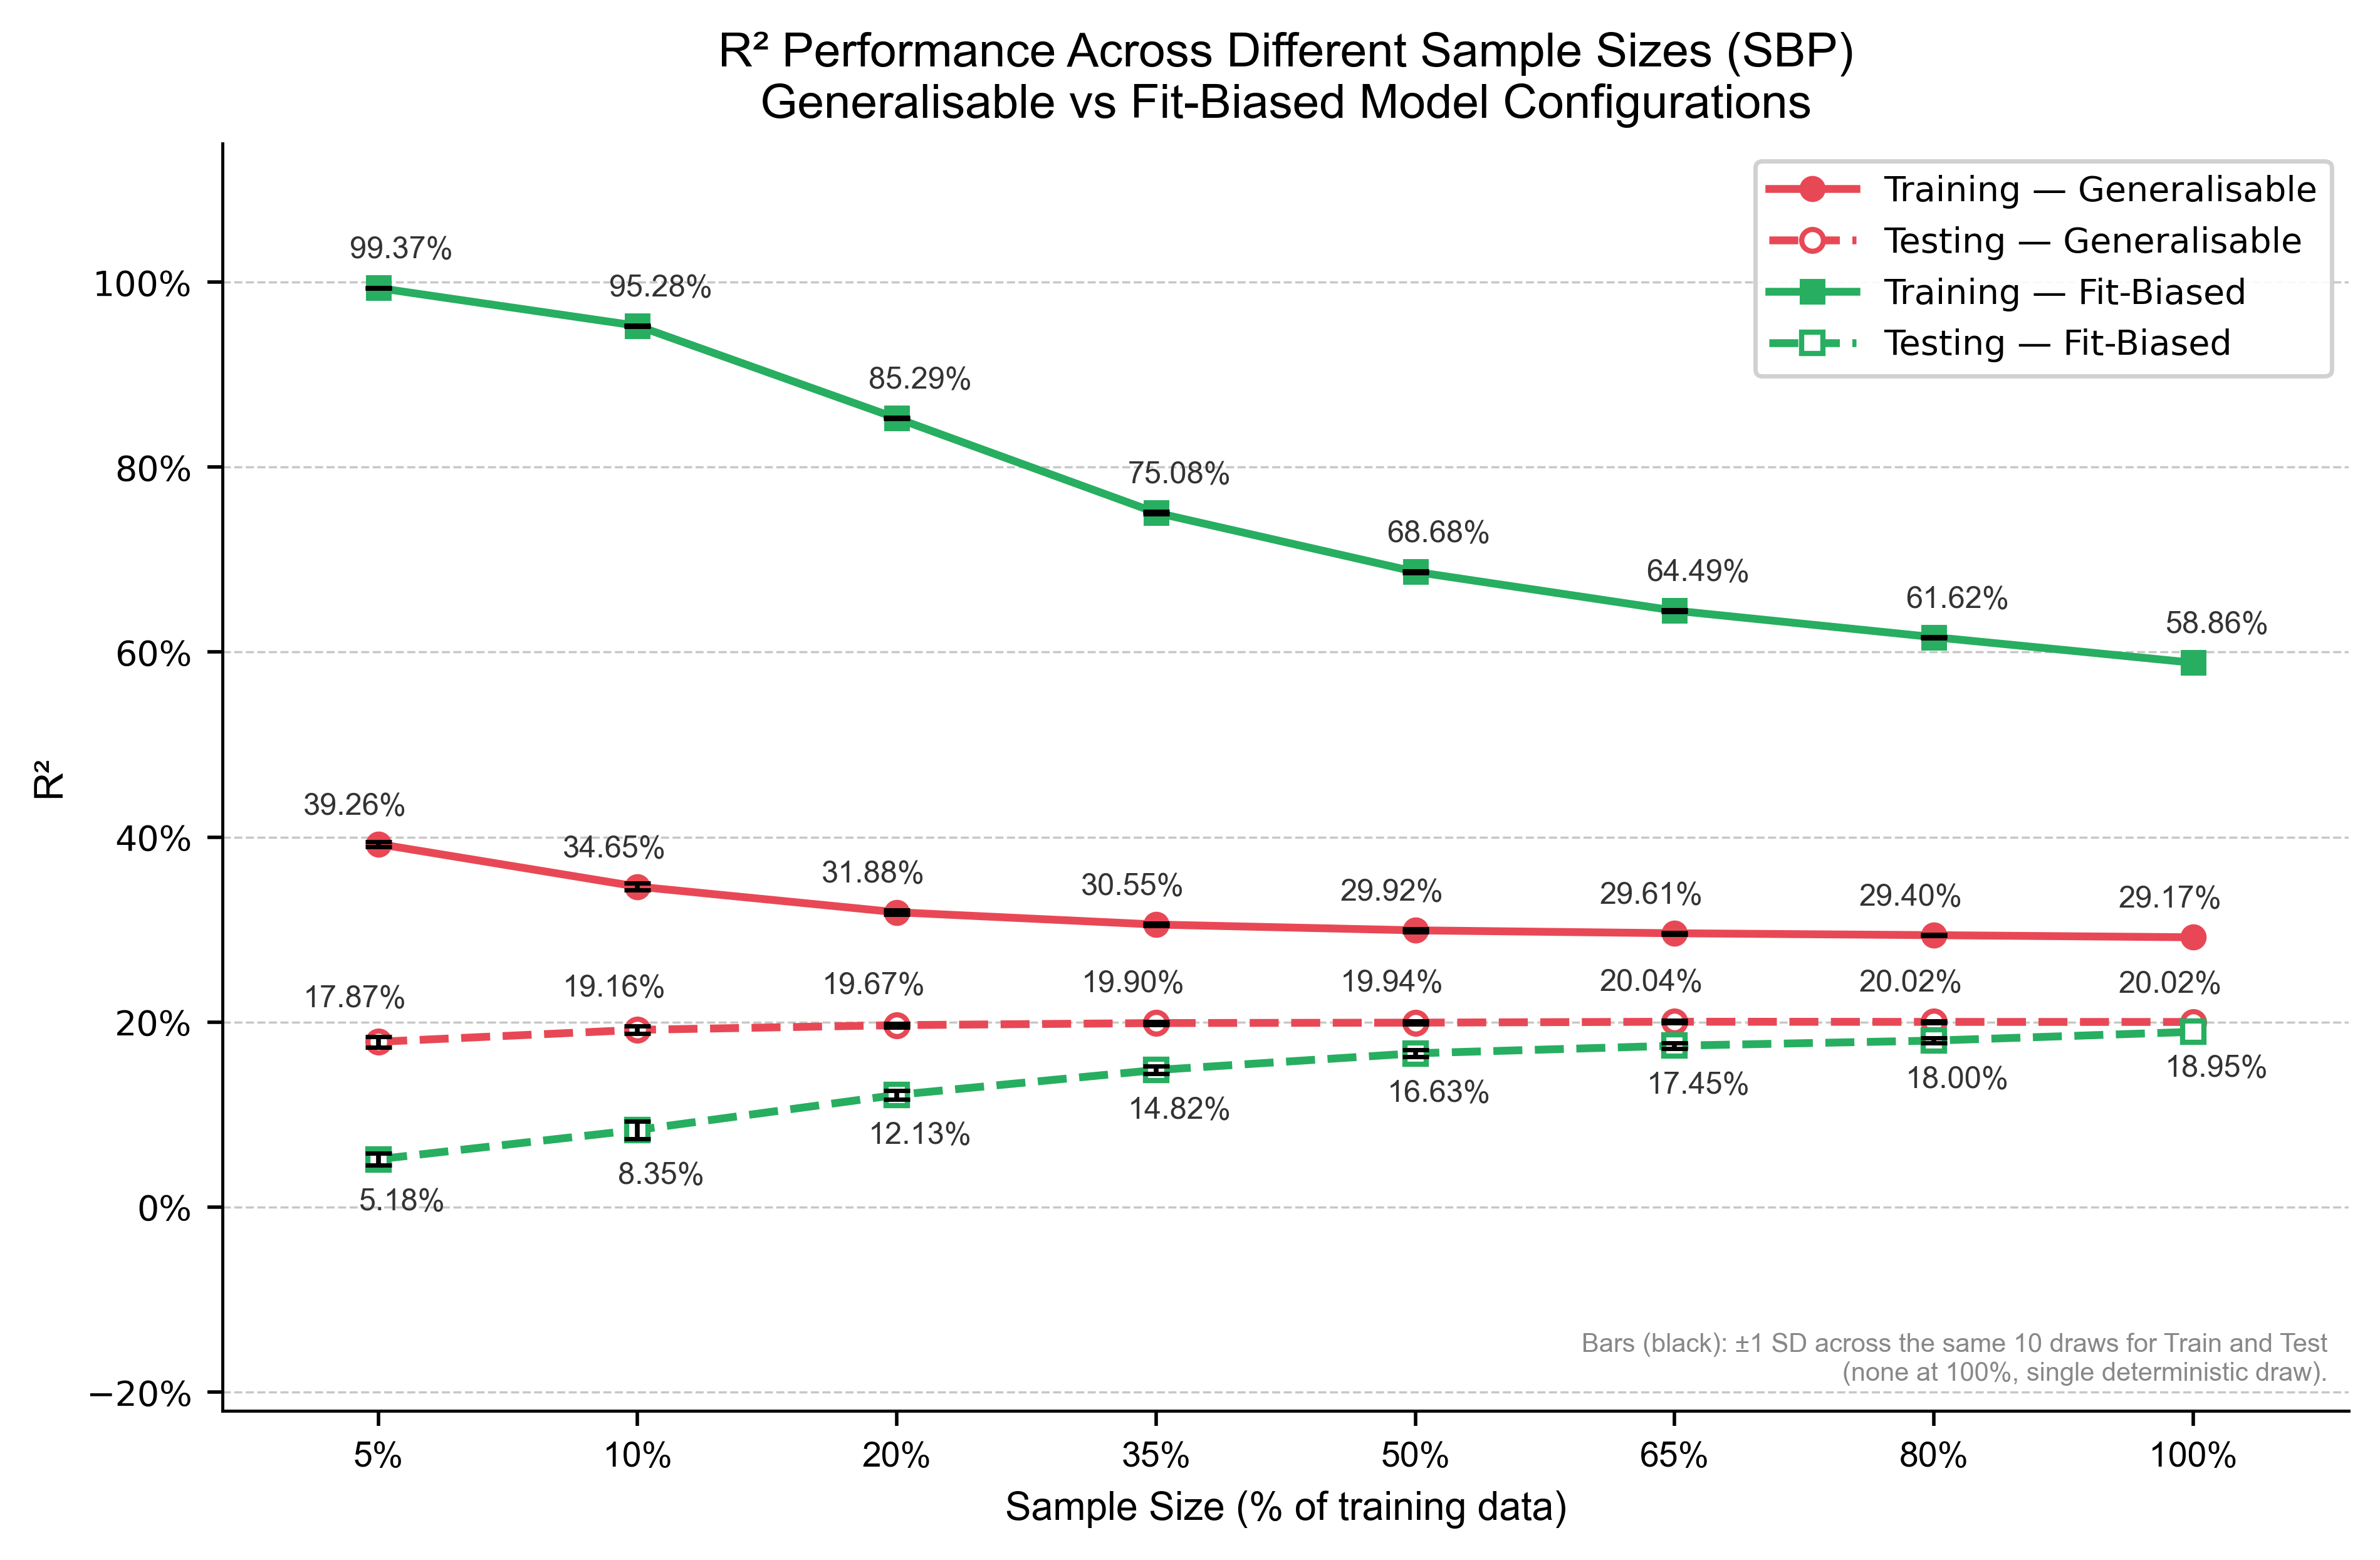

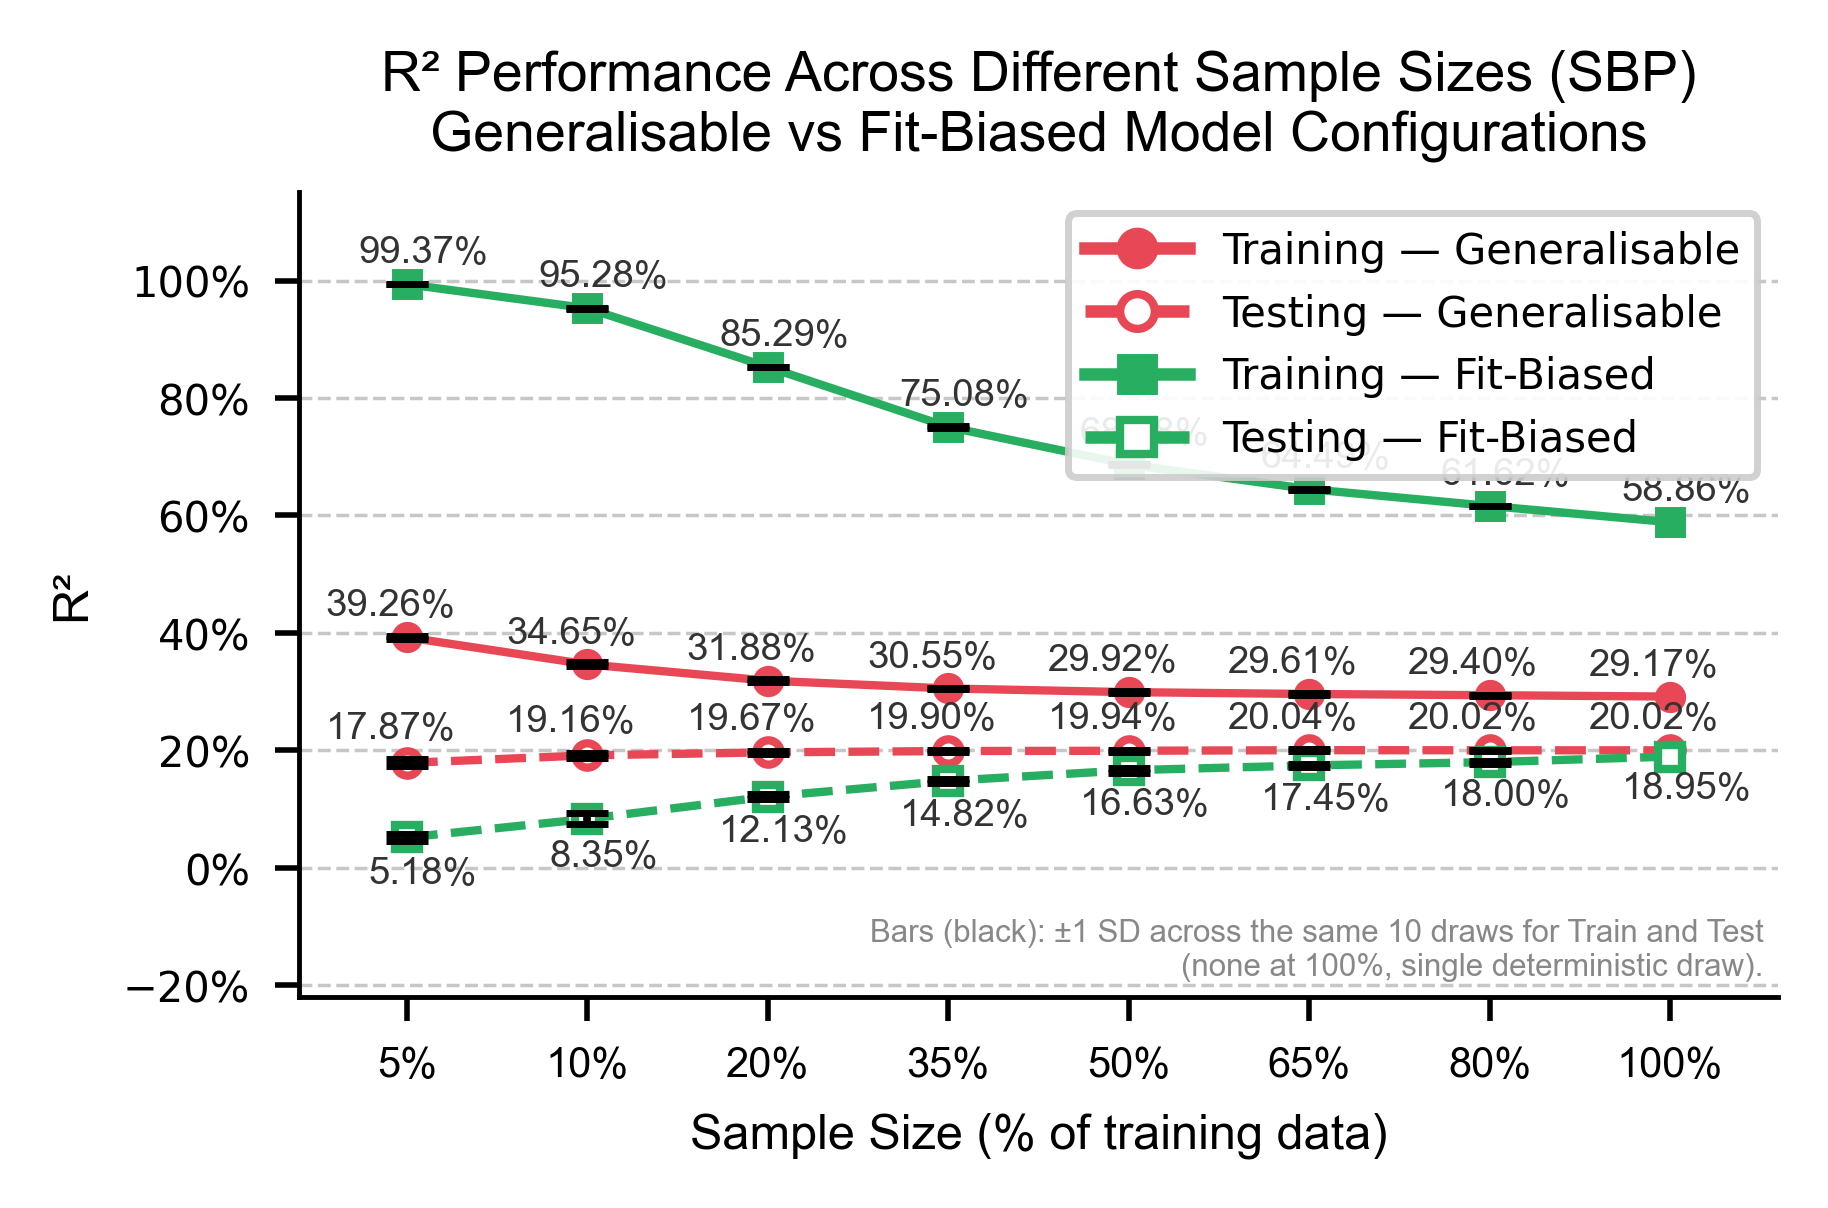

In [35]:
# ── Palette (consistent with Fig 6) ──────────────────────────────────────────
COLOR_GEN   = "#E84855"   # Watermelon → Generalisable
COLOR_FB    = "#27AE60"   # Green      → Fit-Biased
COLOR_LABEL = "#333333"   # dark gray for all data labels
COLOR_ERR   = "black"     # error bars — drawn on top of markers, always visible
LW          = 1.8
MS          = 5
LABEL_X_OFF = 0.09  # small horizontal nudge for label text only (Generalisable
                     # left, Fit-Biased right), purely cosmetic so red/green
                     # text doesn't sit on the same x column — bars themselves
                     # are never dodged here, since they don't overlap on this
                     # ablation (unlike Subject Size at low N)
Y_LIM       = (-22, 115)
LABEL_Y_MARGIN = 3  # keep data labels at least this far from the y-axis edges,
                     # so a large error bar near the bottom/top of the range
                     # doesn't push its label into the axis tick text


def get_band(variant, target, x_vals, subset):
    """Mean R² (%) ± 1 SD across independent training draws, per level, for
    the given subset ('Train' or 'Test') — both curves use the identical
    repeat set, so both get the same treatment. Zero-variance levels
    (single deterministic draw, e.g. 100%) get 0 SD."""
    means, stds = [], []
    for x in x_vals:
        df = load_level(variant, x)
        vals = df.loc[(df["target"] == target) & (df["subset"] == subset), "R2"] * 100
        means.append(vals.mean())
        stds.append(vals.std(ddof=1) if len(vals) > 1 else 0.0)
    return np.array(means), np.array(stds)


def _mask_zero_err(err):
    """NaN out exactly-zero SD entries so matplotlib draws no bar/cap at all
    for deterministic (single-draw) levels, instead of a zero-height tick."""
    return np.where(err == 0, np.nan, err)


def _clip_label_y(y):
    return float(np.clip(y, Y_LIM[0] + LABEL_Y_MARGIN, Y_LIM[1] - LABEL_Y_MARGIN))


def _add_labels(ax, xi, vals, va, y_off, x_off, fs):
    for i, v in enumerate(vals):
        if not np.isnan(v):
            ax.text(
                xi[i] + x_off, _clip_label_y(v + y_off),
                f"{v:.2f}%",
                ha="center", va=va,
                fontsize=fs, fontfamily=FONT_FAMILY,
                color=COLOR_LABEL,
            )


def _add_paired_labels(ax, xi, vals_a, err_a, x_off_a, vals_b, err_b, x_off_b, y_off, fs):
    """Label two curves that converge/cross (e.g. gen_te vs fb_te): at each
    point, the higher value's label goes above and the lower value's label
    goes below, decided per-point rather than by a fixed index range — a
    fixed range only works for one specific grid size and breaks as soon as
    the number of levels changes. Padding is y_off PLUS that point's own
    error-bar size (err_a/err_b, raw — not the NaN-masked version — so 0 at
    deterministic levels just falls back to y_off) so the label clears its
    own whisker cap instead of overlapping it when the SD is large — then
    clipped to stay LABEL_Y_MARGIN away from the axis edges, since a huge
    whisker near the bottom/top of the range would otherwise push the label
    into the axis tick text instead of just past its own cap."""
    for i in range(len(xi)):
        a, b = vals_a[i], vals_b[i]
        if np.isnan(a) or np.isnan(b):
            continue
        va_a, va_b = ("bottom", "top") if a >= b else ("top", "bottom")
        pad_a = y_off + (err_a[i] if not np.isnan(err_a[i]) else 0.0)
        pad_b = y_off + (err_b[i] if not np.isnan(err_b[i]) else 0.0)
        ax.text(xi[i] + x_off_a, _clip_label_y(a + (pad_a if va_a == "bottom" else -pad_a)),
                f"{a:.2f}%", ha="center", va=va_a, fontsize=fs,
                fontfamily=FONT_FAMILY, color=COLOR_LABEL)
        ax.text(xi[i] + x_off_b, _clip_label_y(b + (pad_b if va_b == "bottom" else -pad_b)),
                f"{b:.2f}%", ha="center", va=va_b, fontsize=fs,
                fontfamily=FONT_FAMILY, color=COLOR_LABEL)


def make_sample_size_fig(width_in: float, target: str = TARGET):
    height_in = width_in * ASPECT
    is_small  = width_in < 5
    label_fs  = 5.5 if is_small else 7.0
    tick_fs   = 6   if is_small else 8
    title_fs  = 7   if is_small else 10
    leg_fs    = 6   if is_small else 8
    note_fs   = 4.5 if is_small else 6.0
    lw        = 1.2 if is_small else LW
    ms        = 3.5 if is_small else MS

    xi = np.arange(len(PROPORTIONS))

    fig, ax = plt.subplots(
        figsize=(width_in, height_in),
        dpi=DPI,
        layout="constrained",
    )

    gen_tr, gen_tr_err = get_band("Generalisable", target, PROPORTIONS, "Train")
    gen_te, gen_te_err = get_band("Generalisable", target, PROPORTIONS, "Test")
    fb_tr,  fb_tr_err  = get_band("FitBiased", target, PROPORTIONS, "Train")
    fb_te,  fb_te_err  = get_band("FitBiased", target, PROPORTIONS, "Test")

    # Both Train and Test: mean line + colored marker (zorder=3), with the
    # ±1 SD error bar (across the same 10 repeat draws) drawn separately in
    # black on top (zorder=4), both sitting at the plain tick — this way a
    # bar is always visible as a small black tick even when its span is
    # smaller than the marker itself, instead of disappearing under it.
    # Exactly-zero SD (deterministic single-draw levels) is masked to NaN so
    # no bar/cap renders there at all.
    ax.plot(xi, gen_tr, color=COLOR_GEN, ls="-", marker="o", lw=lw, ms=ms, zorder=3)
    ax.errorbar(xi, gen_tr, yerr=_mask_zero_err(gen_tr_err), fmt="none", ecolor=COLOR_ERR,
                capsize=3, capthick=1, elinewidth=1.1, zorder=4)
    ax.plot(xi, gen_te, color=COLOR_GEN, ls="--", marker="o", lw=lw, ms=ms, zorder=3,
            markerfacecolor="white", markeredgewidth=1.2)
    ax.errorbar(xi, gen_te, yerr=_mask_zero_err(gen_te_err), fmt="none", ecolor=COLOR_ERR,
                capsize=3, capthick=1, elinewidth=1.1, zorder=4)
    ax.plot(xi, fb_tr, color=COLOR_FB, ls="-", marker="s", lw=lw, ms=ms, zorder=3)
    ax.errorbar(xi, fb_tr, yerr=_mask_zero_err(fb_tr_err), fmt="none", ecolor=COLOR_ERR,
                capsize=3, capthick=1, elinewidth=1.1, zorder=4)
    ax.plot(xi, fb_te, color=COLOR_FB, ls="--", marker="s", lw=lw, ms=ms, zorder=3,
            markerfacecolor="white", markeredgewidth=1.2)
    ax.errorbar(xi, fb_te, yerr=_mask_zero_err(fb_te_err), fmt="none", ecolor=COLOR_ERR,
                capsize=3, capthick=1, elinewidth=1.1, zorder=4)

    # Data labels: Train curves are well-separated from everything, always above.
    # Test curves converge/cross, so pick above/below per-point based on which
    # is higher at that x — avoids the overlap a fixed top/bottom split
    # produces once they're this close together.
    _add_labels(ax, xi, gen_tr, "bottom", +2.5, -LABEL_X_OFF, label_fs)
    _add_labels(ax, xi, fb_tr,  "bottom", +2.5, +LABEL_X_OFF, label_fs)
    _add_paired_labels(ax, xi, gen_te, gen_te_err, -LABEL_X_OFF, fb_te, fb_te_err, +LABEL_X_OFF, 2.5, label_fs)

    # Axes
    ax.set_xticks(xi)
    ax.set_xticklabels(X_LABELS, fontsize=tick_fs, fontfamily=FONT_FAMILY)
    ax.set_xlim(-0.6, len(PROPORTIONS) - 0.4)
    ax.set_ylim(*Y_LIM)
    ax.yaxis.set_major_locator(mticker.MultipleLocator(20))
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=100, decimals=0))
    ax.set_xlabel(
        "Sample Size (% of training data)",
        fontsize=tick_fs + 1, fontfamily=FONT_FAMILY,
    )
    ax.set_ylabel("R²", fontsize=tick_fs + 1, fontfamily=FONT_FAMILY)

    apply_base_style(ax, grid_axis="y")
    ax.tick_params(axis="both", labelsize=tick_fs)

    # Legend: filled marker = Training, hollow marker = Testing
    legend_elements = [
        Line2D([0],[0], color=COLOR_GEN, ls="-",  marker="o", lw=LW, ms=MS,
               label="Training — Generalisable"),
        Line2D([0],[0], color=COLOR_GEN, ls="--", marker="o", lw=LW, ms=MS,
               markerfacecolor="white", markeredgewidth=1.2,
               label="Testing — Generalisable"),
        Line2D([0],[0], color=COLOR_FB,  ls="-",  marker="s", lw=LW, ms=MS,
               label="Training — Fit-Biased"),
        Line2D([0],[0], color=COLOR_FB,  ls="--", marker="s", lw=LW, ms=MS,
               markerfacecolor="white", markeredgewidth=1.2,
               label="Testing — Fit-Biased"),
    ]
    ax.legend(
        handles=legend_elements,
        loc="upper right", ncol=1,
        fontsize=leg_fs,
        handlelength=2.5,
        frameon=True, framealpha=0.9, edgecolor="#CCCCCC",
    )

    ax.text(
        0.99, 0.02,
        "Bars (black): ±1 SD across the same 10 draws for Train and Test\n"
        "(none at 100%, single deterministic draw).",
        transform=ax.transAxes, ha="right", va="bottom",
        fontsize=note_fs, fontfamily=FONT_FAMILY, color="#888888",
    )

    ax.set_title(
        f"R² Performance Across Different Sample Sizes ({target})\n"
        "Generalisable vs Fit-Biased Model Configurations",
        fontsize=title_fs + 1,
        fontfamily=FONT_FAMILY,
    )
    return fig


fig_full   = make_sample_size_fig(W_FULL)
fig_single = make_sample_size_fig(W_SINGLE)

save_fig(fig_full,   f"Fig_Ablation_SampleSize_{TARGET}_full",   FIG_OUT)
save_fig(fig_single, f"Fig_Ablation_SampleSize_{TARGET}_single", FIG_OUT)

print(f"Full-page  : {round(W_FULL*DPI)} × {round(W_FULL*ASPECT*DPI)} px")
print(f"Single-col : {round(W_SINGLE*DPI)} × {round(W_SINGLE*ASPECT*DPI)} px")
plt.show()

## 3 · Verify pixel counts

In [36]:
from PIL import Image

for fname, req_w in [
    (f"Fig_Ablation_SampleSize_{TARGET}_full.png",   MIN_PX_FULL),
    (f"Fig_Ablation_SampleSize_{TARGET}_single.png", MIN_PX_SINGLE),
]:
    with Image.open(FIG_OUT / fname) as im:
        w, h = im.size
    ok = "\u2705" if w >= req_w else "\u274c"
    print(f"{ok} {fname}: {w} \u00d7 {h} px  (min required: {req_w} px wide)")

✅ Fig_Ablation_SampleSize_SBP_full.png: 3798 × 2489 px  (min required: 3740 px wide)
✅ Fig_Ablation_SampleSize_SBP_single.png: 1828 × 1208 px  (min required: 1772 px wide)
